### Actividad 5 — Conjuntos de entrenamiento y prueba

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import random

random.seed(1234)
df = pd.read_csv('../data/data_divorce.csv')

### Variable respuesta: ZONA (Urbana / Rural)

Se construye la variable respuesta a partir de  (departamento de ocurrencia del divorcio). Los departamentos se clasifican como **urbanos** si cuentan con mayor densidad poblacional, infraestructura institucional y cobertura de juzgados de familia según el OJ (2022). El resto se considera **rural**. <br><br>

"Dadas las características socioeconómicas y demográficas de la pareja (educación, etnia, edad, ocupación), ¿el divorcio se registrará en una zona urbana o rural?" 

In [3]:
# Departamentos con mayor urbanización e infraestructura judicial
deptos_urbanos = ['Guatemala', 'Escuintla', 'Sacatepequez',
                  'Quetzaltenango', 'Retalhuleu', 'Chimaltenango']

df['ZONA'] = df['DEPOCU'].apply(lambda x: 'Urbana' if x in deptos_urbanos else 'Rural')

df['ZONA'].value_counts()

ZONA
Urbana    40564
Rural     31012
Name: count, dtype: int64

### Balance de clases

Se examina si la variable respuesta está balanceada, ya que un desbalance significativo afecta la capacidad del modelo para predecir la clase minoritaria.

        Frecuencia  Porcentaje (%)
ZONA                              
Urbana       40564            56.7
Rural        31012            43.3


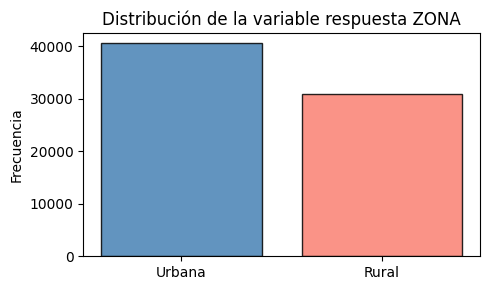

In [4]:
# Distribución absoluta y porcentual
conteo = df['ZONA'].value_counts()
pct = df['ZONA'].value_counts(normalize=True).round(3) * 100

balance_df = pd.DataFrame({'Frecuencia': conteo, 'Porcentaje (%)': pct})
print(balance_df)

plt.figure(figsize=(5, 3))
plt.bar(conteo.index, conteo.values, color=['steelblue', 'salmon'], edgecolor='black', alpha=0.85)
plt.title('Distribución de la variable respuesta ZONA')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Se observa que la distribución entre zona urbana (56.7%) y rural (43.3%) presenta un desbalance moderado, pero no crítico. Se utilizará el parámetro  en los modelos de Regresión Logística y Random Forest para compensar esta diferencia y evitar que el modelo favorezca sistemáticamente la clase mayoritaria.

### Análisis de atípicos en variables numéricas

Se aplica el método IQR para identificar valores atípicos.

In [5]:
# Convertir edades a numérico (Ignorado → NaN)
df['EDADHOM'] = pd.to_numeric(df['EDADHOM'], errors='coerce')
df['EDADMUJ'] = pd.to_numeric(df['EDADMUJ'], errors='coerce')

# Función para calcular límites IQR
def limites_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, Q1, Q3, IQR

for col in ['EDADHOM', 'EDADMUJ']:
    lower, upper, Q1, Q3, IQR = limites_iqr(df[col].dropna())
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, límites=[{lower:.1f}, {upper:.1f}], atípicos={n_out}')

EDADHOM: Q1=29.0, Q3=41.0, IQR=12.0, límites=[11.0, 59.0], atípicos=1194
EDADMUJ: Q1=26.0, Q3=38.0, IQR=12.0, límites=[8.0, 56.0], atípicos=788


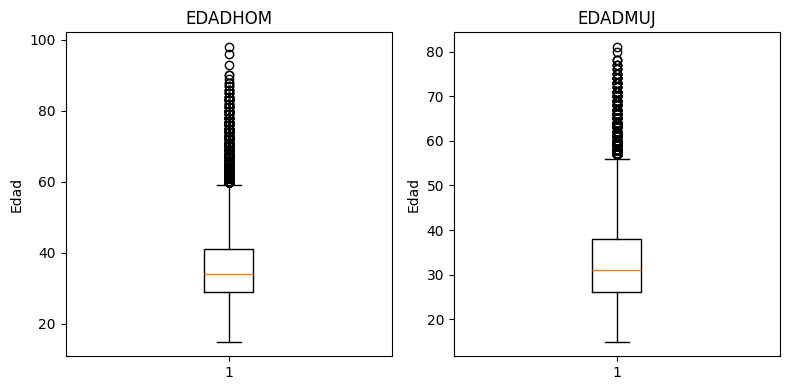

In [6]:
# Boxplots de edades
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, col in zip(axes, ['EDADHOM', 'EDADMUJ']):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel('Edad')
plt.tight_layout()
plt.show()

Se observa que  presenta 1,194 valores atípicos (edades por encima de 59 años) y  presenta 788 (edades por encima de 56 años). Estos registros corresponden a parejas de mayor edad al momento del divorcio, valores biológicamente posibles. Por ello, **no se eliminan** sino que se mantienen en el conjunto de datos; los algoritmos de árbol (Random Forest) son robustos ante atípicos por naturaleza, y para Regresión Logística el escalado posterior reducirá su influencia.

### División en conjuntos de entrenamiento y prueba

Se utiliza una partición 70/30, estratificada por la variable respuesta , para garantizar que ambas clases (Urbana/Rural) estén representadas proporcionalmente en ambos conjuntos.

In [7]:
# Variables predictoras seleccionadas
X = df[['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ', 'OCUHOM', 'OCUMUJ', 'EDADHOM', 'EDADMUJ']]
y = df['ZONA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, train_size=0.7, stratify=y, random_state=1234
)

print(f'Train: {X_train.shape[0]} registros ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} registros ({X_test.shape[0]/len(df)*100:.1f}%)')

Train: 50103 registros (70.0%)
Test:  21473 registros (30.0%)


In [8]:
# Verificar que el balance se mantuvo en ambos conjuntos
print('Train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test: ', y_test.value_counts(normalize=True).round(3).to_dict())

Train: {'Urbana': 0.567, 'Rural': 0.433}
Test:  {'Urbana': 0.567, 'Rural': 0.433}


## Actividad 6 — Preprocesamiento y transformaciones

### Tratamiento de valores Ignorado

Para las variables categóricas se imputan con la **moda** del conjunto de entrenamiento. Para las variables numéricas (edades), los  generados en la conversión anterior se imputan con la **mediana**, que es más robusta ante los atípicos identificados.

In [9]:
# Variables categóricas y numéricas
cat_cols = ['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ', 'OCUHOM', 'OCUMUJ']
num_cols = ['EDADHOM', 'EDADMUJ']

# Reemplazar 'Ignorado' por NaN en categóricas para imputar uniformemente
X_train = X_train.copy()
X_test  = X_test.copy()

for col in cat_cols:
    X_train[col] = X_train[col].replace('Ignorado', np.nan)
    X_test[col]  = X_test[col].replace('Ignorado', np.nan)

# Imputar categóricas con moda del train
for col in cat_cols:
    moda = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(moda)
    X_test[col]  = X_test[col].fillna(moda)

# Imputar numéricas con mediana del train
for col in num_cols:
    mediana = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediana)
    X_test[col]  = X_test[col].fillna(mediana)

print('Nulos restantes en train:', X_train.isnull().sum().sum())
print('Nulos restantes en test: ', X_test.isnull().sum().sum())

Nulos restantes en train: 0
Nulos restantes en test:  0


## Agrupación de OCUHOM y OCUMUJ

Las variables de ocupación contienen 181 y 125 categorías respectivamente, lo que generaría una dimensionalidad excesiva al aplicar One-Hot Encoding. Se agrupan en 5 categorías basadas en el tipo de actividad económica.

In [10]:
# Mapeo de ocupaciones a grupos simplificados
def agrupar_ocupacion(val):
    val = str(val).lower()
    if any(p in val for p in ['agro', 'peon', 'agricu', 'pesqu', 'forest']):
        return 'Agropecuaria'
    elif any(p in val for p in ['profesional', 'ciencia', 'ingeni', 'derecho', 'salud', 'enseñanza']):
        return 'Profesional'
    elif any(p in val for p in ['vend', 'comerci', 'mercado']):
        return 'Comercio'
    elif any(p in val for p in ['construc', 'metalur', 'operari', 'maquina', 'conductor']):
        return 'Operario/Construccion'
    else:
        return 'Otro'

X_train['OCUHOM'] = X_train['OCUHOM'].apply(agrupar_ocupacion)
X_test['OCUHOM']  = X_test['OCUHOM'].apply(agrupar_ocupacion)
X_train['OCUMUJ'] = X_train['OCUMUJ'].apply(agrupar_ocupacion)
X_test['OCUMUJ']  = X_test['OCUMUJ'].apply(agrupar_ocupacion)

print(X_train['OCUHOM'].value_counts())

OCUHOM
Otro                     30510
Agropecuaria              7097
Profesional               5434
Operario/Construccion     3940
Comercio                  3122
Name: count, dtype: int64


### Encoding y normalización con ColumnTransformer

Siguiendo el enfoque visto en clase (Ejemplo NB con Carros), se utiliza un  que aplica:
- **OneHotEncoder** a las variables categóricas (, , , , , )
- **StandardScaler** a las variables numéricas (, ), necesario principalmente para Regresión Logística

In [11]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('scaler',  StandardScaler(), num_cols)
])

# Ajustar solo sobre train, transformar ambos
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print('Shape train preprocesado:', X_train_prep.shape)
print('Shape test preprocesado: ', X_test_prep.shape)

Shape train preprocesado: (50103, 38)
Shape test preprocesado:  (21473, 38)


Se observa que tras el encoding, el conjunto de entrenamiento pasa de 8 columnas originales a una dimensión mayor debido a la expansión de las variables categóricas en columnas binarias. Este proceso se ajusta únicamente sobre los datos de entrenamiento para evitar fuga de información (*data leakage*) hacia el conjunto de prueba.

El preprocesador queda listo para ser integrado dentro de los  de cada algoritmo en la siguiente etapa de modelado.